In [2]:
import pickle
import statistics

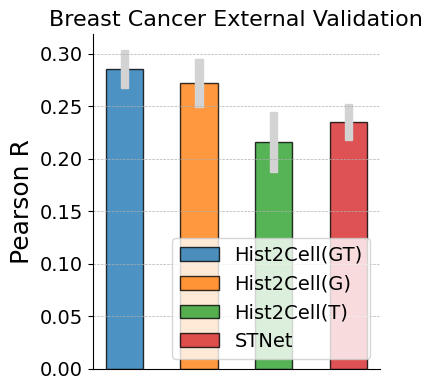

In [7]:
with open('/data1/r20user3/shared_project/Hist2Cell/code/training/pearson_log/breast_cross_source_epoch100_lr1e-4_2hop_ensemble_Trans1layer_GNNoutput50_onlycell_cell_pearson_list.pkl', 'rb') as f:
    multi_cell_pearson_list = pickle.load(f)
ensemble_mean = statistics.mean(multi_cell_pearson_list)
ensemble_std = statistics.variance(multi_cell_pearson_list)

with open('/data1/r20user3/shared_project/Hist2Cell/code/training/pearson_log/breast_cross_source_epoch100_lr1e-4_2hop_rawimgGNN_onlycell_cell_pearson_list.pkl', 'rb') as f:
    multi_cell_pearson_list = pickle.load(f)
gcn_mean = statistics.mean(multi_cell_pearson_list)
gcn_std = statistics.variance(multi_cell_pearson_list)

with open('/data1/r20user3/shared_project/Hist2Cell/code/training/pearson_log/breast_cross_source_epoch100_lr1e-4_2hop_rawimgTrans1layer_onlycell_cell_pearson_list.pkl', 'rb') as f:
    multi_cell_pearson_list = pickle.load(f)
trans_mean = statistics.mean(multi_cell_pearson_list)
trans_std = statistics.variance(multi_cell_pearson_list)

with open('/data1/r20user3/shared_project/Hist2Cell/code/training/pearson_log/breast_cross_source_epoch100_lr1e-4_2hop_densenet_onlycell_cell_pearson_list.pkl', 'rb') as f:
    multi_cell_pearson_list = pickle.load(f)
densenet_mean = statistics.mean(multi_cell_pearson_list)
densenet_std = statistics.variance(multi_cell_pearson_list)

import numpy as np
import matplotlib.pyplot as plt

models = ['Hist2Cell(GT)', 'Hist2Cell(G)', 'Hist2Cell(T)', 'STNet']
accuracy = [ensemble_mean, gcn_mean, trans_mean, densenet_mean]
std_dev = [ensemble_std, gcn_std, trans_std, densenet_std]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Function to draw solid error bars
def draw_solid_error_bars(ax, x, y, errors, width=0.1, color='black'):
    for i in range(len(x)):
        rect = plt.Rectangle((x[i] - width / 2, y[i] - errors[i]), width, errors[i] * 2, color=color)
        ax.add_patch(rect)

# Create a single subplot
fig, ax = plt.subplots(figsize=(4, 4))

# Set the width of each bar
bar_width = 0.5

# Set the x position of each model's bar
x_pos = np.arange(len(models))

# Draw the bar plot with different colors and solid error bars
for i in range(len(models)):
    bar_plot = ax.bar(x_pos[i], accuracy[i], width=bar_width, align='center', alpha=0.8, color=colors[i], label=models[i], edgecolor='black')
    draw_solid_error_bars(ax, [x_pos[i]], [accuracy[i]], [std_dev[i]], width=0.1, color='lightgray')

# Set labels, legend, and title
ax.set_xticks([])
ax.tick_params(axis='x', labelsize=14)  # Set x-axis tick font size
ax.tick_params(axis='y', labelsize=14)  # Set y-axis tick font size     


# ax.set_xticks(x_pos)
# ax.set_xticklabels(models, fontsize=8)
ax.set_ylabel('Pearson R', fontsize=18)
ax.legend(fontsize=14, loc='lower right')
ax.set_title('Breast Cancer External Validation', fontsize=16)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add gridlines
ax.yaxis.grid(True, linestyle='--', linewidth=0.5)

# Save the figure and show
plt.tight_layout()
plt.savefig('/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_bar_with_std_each_case_cross_source/'+'overall'+'.svg', bbox_inches='tight', pad_inches=0)
plt.show()